# VQCFD Gradient and Legacy Variance Analysis

The reusable loading and plotting functions live in `analysis.py`. The first section remains available for old variance-mode results; the new raw-gradient workflow is below.


In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover legacy variance runs


In [3]:
variance_runs = an.discover_variance_runs()
an.print_variance_runs(variance_runs)


var_N2L1                 N=2   L=1   circuit=default    variance=0.31716497156749646 tries=4000
var_N2L2                 N=2   L=2   circuit=default    variance=0.2965365373132682 tries=4000
var_N2L4                 N=2   L=4   circuit=default    variance=0.279785533622202 tries=4000
var_N2L8                 N=2   L=8   circuit=default    variance=0.27073325456218755 tries=2000
var_N3L1                 N=3   L=1   circuit=default    variance=0.1442779785519855 tries=1000
var_N3L2                 N=3   L=2   circuit=default    variance=0.13890475032056604 tries=1000
var_N3L4                 N=3   L=4   circuit=default    variance=0.13305193118477224 tries=1000
var_N3L8                 N=3   L=8   circuit=default    variance=0.1279561159880521 tries=1000
var_N4L1                 N=4   L=1   circuit=default    variance=0.06925700385211589 tries=1000
var_N4L2                 N=4   L=2   circuit=default    variance=0.0664977257100345 tries=1000
var_N4L4                 N=4   L=4   circuit=d

## Select runs


In [4]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
RUNS = [
    # ("var", "N2L1"),
    # ("var", "N3L1"),
]

# Each entry replaces its source runs with one variance computed from all raw gradient samples.
VARIANCE_COMBINATIONS = {
    "combined_N10L1": [("var", f"N10L1_{i}") for i in range(1, 5)],
    "combined_N10L2": [("var", f"N10L2_{i}") for i in range(1, 5)],
}

selected = [an.load_variance_run(d, label) for d, label in RUNS] if RUNS else variance_runs
selected = an.apply_variance_combinations(selected, VARIANCE_COMBINATIONS)
an.print_variance_runs(selected)
an.variance_table(selected)


var_N2L1                 N=2   L=1   circuit=default    variance=0.31716497156749646 tries=4000
var_N2L2                 N=2   L=2   circuit=default    variance=0.2965365373132682 tries=4000
var_N2L4                 N=2   L=4   circuit=default    variance=0.279785533622202 tries=4000
var_N2L8                 N=2   L=8   circuit=default    variance=0.27073325456218755 tries=2000
var_N3L1                 N=3   L=1   circuit=default    variance=0.1442779785519855 tries=1000
var_N3L2                 N=3   L=2   circuit=default    variance=0.13890475032056604 tries=1000
var_N3L4                 N=3   L=4   circuit=default    variance=0.13305193118477224 tries=1000
var_N3L8                 N=3   L=8   circuit=default    variance=0.1279561159880521 tries=1000
var_N4L1                 N=4   L=1   circuit=default    variance=0.06925700385211589 tries=1000
var_N4L2                 N=4   L=2   circuit=default    variance=0.0664977257100345 tries=1000
var_N4L4                 N=4   L=4   circuit=d

,full_label,n,l,circuit,variance,variance_tries,variance_num_samples,variance_runtime_s,gradient_mean,combined_from
0,var_N2L1,2,1,default,0.317165,4000,16000,5.563150e+03,NaN,NaN
1,var_N2L2,2,2,default,0.296537,4000,24000,5.948666e+03,NaN,NaN
2,var_N2L4,2,4,default,0.279786,4000,40000,1.535361e+04,NaN,NaN
3,var_N2L8,2,8,default,0.270733,2000,36000,2.388916e+04,NaN,NaN
4,var_N3L1,3,1,default,0.144278,1000,6000,6.930896e+02,NaN,NaN
5,var_N3L2,3,2,default,0.138905,1000,9000,1.399477e+03,NaN,NaN
6,var_N3L4,3,4,default,0.133052,1000,15000,9.662871e+03,NaN,NaN
7,var_N3L8,3,8,default,0.127956,1000,27000,3.035134e+04,NaN,NaN
8,var_N4L1,4,1,default,0.069257,1000,8000,3.053449e+03,NaN,NaN
9,var_N4L2,4,2,default,0.066498,1000,12000,2.358635e+03,NaN,NaN


## Variance plots


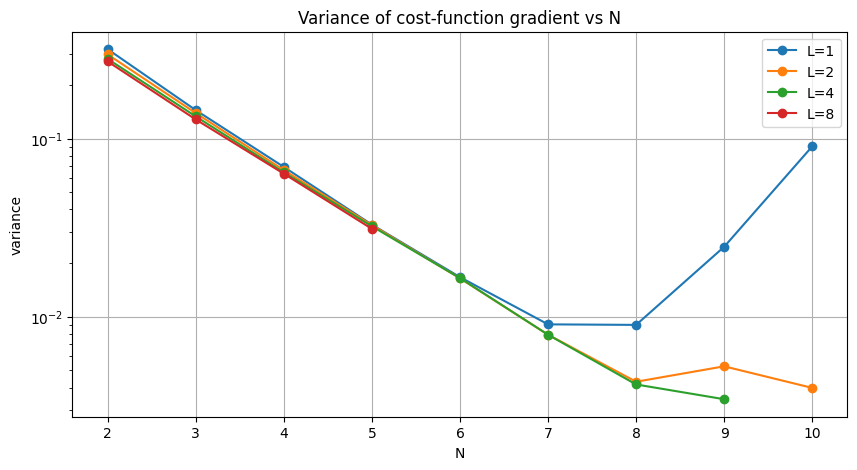

In [5]:
an.plot_variance_vs_n(selected, log_y=True);


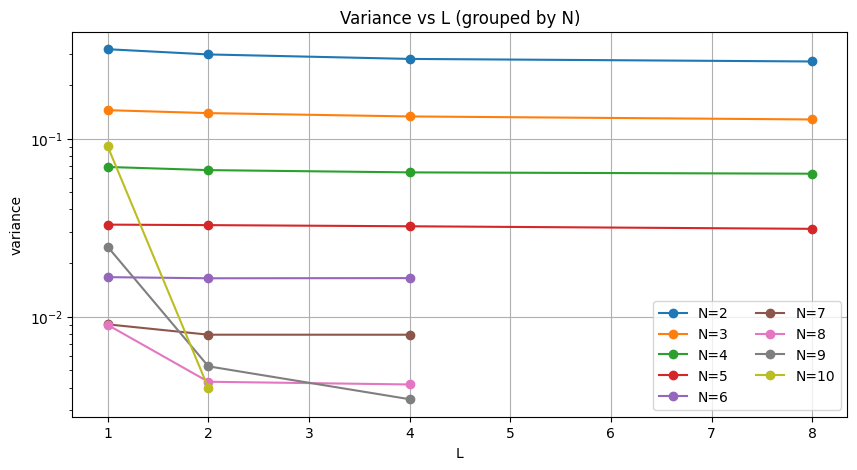

In [12]:
an.plot_variance_vs_l(selected, log_y=True);


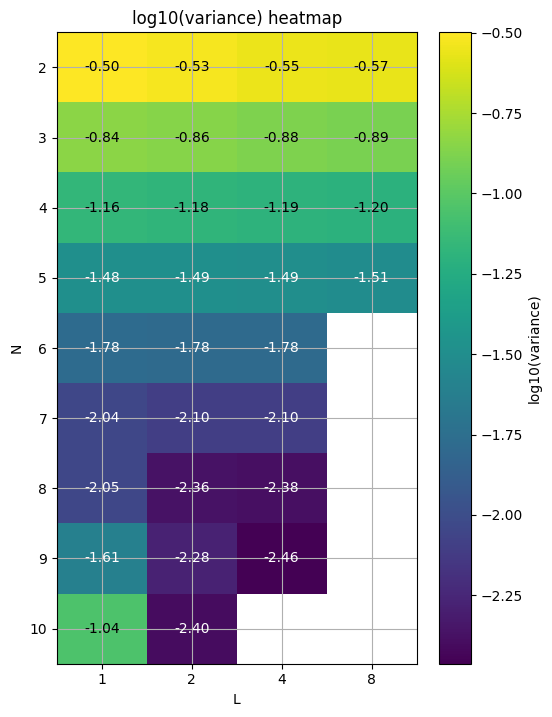

In [6]:
an.plot_variance_heatmap(selected);


## Inspect one run


In [5]:
if selected:
    selected[0]["values"]


## Discover and select gradient runs

Each run contains two aligned parameter-by-sweep matrices: `current_dt` and `fixed_diffusion`.


In [59]:
gradient_runs = an.discover_gradient_runs()
an.print_gradient_runs(gradient_runs)


tests_N2L1                       N=2   L=1   circuit=default              gradients=5000/5000
tests_N2L2                       N=2   L=2   circuit=default              gradients=4998/5000
tests_N2L4                       N=2   L=4   circuit=default              gradients=5000/5000
tests_N3L1                       N=3   L=1   circuit=default              gradients=4998/5000
tests_N3L2                       N=3   L=2   circuit=default              gradients=4995/5000
tests_N3L4                       N=3   L=4   circuit=default              gradients=4995/5000
tests_N4L1                       N=4   L=1   circuit=default              gradients=5000/5000
tests_N4L2                       N=4   L=2   circuit=default              gradients=4992/5000
tests_N4L4                       N=4   L=4   circuit=default              gradients=5000/5000
tests_N5L1                       N=5   L=1   circuit=default              gradients=7000/7000
tests_N5L2                       N=5   L=2   circuit=default

In [60]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
GRADIENT_RUNS = [
    # ("grad", "N2L1"),
    # ("grad", "N3L1"),
]

selected_gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_RUNS]
    if GRADIENT_RUNS else gradient_runs
)
an.print_gradient_runs(selected_gradient_runs)


tests_N2L1                       N=2   L=1   circuit=default              gradients=5000/5000
tests_N2L2                       N=2   L=2   circuit=default              gradients=4998/5000
tests_N2L4                       N=2   L=4   circuit=default              gradients=5000/5000
tests_N3L1                       N=3   L=1   circuit=default              gradients=4998/5000
tests_N3L2                       N=3   L=2   circuit=default              gradients=4995/5000
tests_N3L4                       N=3   L=4   circuit=default              gradients=4995/5000
tests_N4L1                       N=4   L=1   circuit=default              gradients=5000/5000
tests_N4L2                       N=4   L=2   circuit=default              gradients=4992/5000
tests_N4L4                       N=4   L=4   circuit=default              gradients=5000/5000
tests_N5L1                       N=5   L=1   circuit=default              gradients=7000/7000
tests_N5L2                       N=5   L=2   circuit=default

## Statistics over all parameters

`mean_gradient` and `variance` pool every scalar gradient. `mean_gradient_norm` is the mean L2 norm of the complete gradient vector over random-parameter sweeps.


In [61]:
gradient_run_stats = an.gradient_run_table(selected_gradient_runs)
gradient_run_stats


,full_label,n,l,circuit,initial_state,dataset,diffusion_number,dt,number_of_parameters,gradient_sweeps,gradient_num_samples,gradient_tries_requested,mean_gradient,mean_gradient_norm,variance,gradient_runtime_s
0,tests_N2L1,2,1,default,sine,current_dt,0.0009,0.010000,4,1250,5000,5000,-0.029075,0.960802,0.249777,128.662015
1,tests_N2L1,2,1,default,sine,fixed_diffusion,0.1000,1.111111,4,1250,5000,5000,-0.055959,1.793586,0.869764,128.662015
2,tests_N2L2,2,2,default,sine,current_dt,0.0009,0.010000,6,833,4998,5000,0.000543,1.198506,0.254142,182.880006
3,tests_N2L2,2,2,default,sine,fixed_diffusion,0.1000,1.111111,6,833,4998,5000,0.000947,2.237437,0.885633,182.880006
4,tests_N2L4,2,4,default,sine,current_dt,0.0009,0.010000,10,500,5000,5000,-0.006844,1.557438,0.254612,290.141031
5,tests_N2L4,2,4,default,sine,fixed_diffusion,0.1000,1.111111,10,500,5000,5000,-0.011728,2.905751,0.886397,290.141031
6,tests_N3L1,3,1,default,sine,current_dt,0.0049,0.010000,6,833,4998,5000,0.008934,0.842399,0.125151,201.431231
7,tests_N3L1,3,1,default,sine,fixed_diffusion,0.1000,0.204082,6,833,4998,5000,0.004572,0.829861,0.121247,201.431231
8,tests_N3L2,3,2,default,sine,current_dt,0.0049,0.010000,9,555,4995,5000,-0.004561,1.031704,0.123226,290.584083
9,tests_N3L2,3,2,default,sine,fixed_diffusion,0.1000,0.204082,9,555,4995,5000,-0.004612,1.002199,0.116338,290.584083


## Statistics for each parameter

For a single scalar parameter, its gradient norm is its absolute value, so `mean_gradient_norm` is the mean absolute gradient.


In [62]:
gradient_parameter_stats = an.gradient_parameter_table(selected_gradient_runs)
gradient_parameter_stats


,full_label,n,l,circuit,initial_state,dataset,diffusion_number,dt,number_of_parameters,parameter_index,parameter,gradient_sweeps,mean_gradient,mean_gradient_norm,variance
0,tests_N2L1,2,1,default,sine,current_dt,0.0009,0.010000,4,0,theta_0,1250,-0.111781,0.443034,0.244563
1,tests_N2L1,2,1,default,sine,current_dt,0.0009,0.010000,4,1,theta_1,1250,-0.004340,0.436279,0.250961
2,tests_N2L1,2,1,default,sine,current_dt,0.0009,0.010000,4,2,theta_2,1250,0.041635,0.425070,0.245495
3,tests_N2L1,2,1,default,sine,current_dt,0.0009,0.010000,4,3,theta_3,1250,-0.041813,0.425043,0.245477
4,tests_N2L1,2,1,default,sine,fixed_diffusion,0.1000,1.111111,4,0,theta_0,1250,-0.208871,0.827480,0.853401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,tests_N5L4,5,4,default,sine,fixed_diffusion,0.1000,0.010406,25,20,theta_20,280,-0.003087,0.134441,0.029840
276,tests_N5L4,5,4,default,sine,fixed_diffusion,0.1000,0.010406,25,21,theta_21,280,-0.000894,0.134511,0.031319
277,tests_N5L4,5,4,default,sine,fixed_diffusion,0.1000,0.010406,25,22,theta_22,280,-0.016606,0.140884,0.033848
278,tests_N5L4,5,4,default,sine,fixed_diffusion,0.1000,0.010406,25,23,theta_23,280,-0.017732,0.144844,0.032481


## Configurable plots for overall gradient statistics

Choose any columns from `gradient_run_stats` for the x- and y-axes. Filters can be scalars, lists, or `None`. `GROUP_BY` can be one column, multiple columns, or `None`; include `dataset` when plotting both coefficient variants.


,full_label,n,l,circuit,initial_state,dataset,diffusion_number,dt,number_of_parameters,gradient_sweeps,gradient_num_samples,gradient_tries_requested,mean_gradient,mean_gradient_norm,variance,gradient_runtime_s
0,tests_N2L1,2,1,default,sine,current_dt,0.0009,0.010000,4,1250,5000,5000,-0.029075,0.960802,0.249777,128.662015
1,tests_N2L1,2,1,default,sine,fixed_diffusion,0.1000,1.111111,4,1250,5000,5000,-0.055959,1.793586,0.869764,128.662015
2,tests_N2L2,2,2,default,sine,current_dt,0.0009,0.010000,6,833,4998,5000,0.000543,1.198506,0.254142,182.880006
3,tests_N2L2,2,2,default,sine,fixed_diffusion,0.1000,1.111111,6,833,4998,5000,0.000947,2.237437,0.885633,182.880006
4,tests_N2L4,2,4,default,sine,current_dt,0.0009,0.010000,10,500,5000,5000,-0.006844,1.557438,0.254612,290.141031
5,tests_N2L4,2,4,default,sine,fixed_diffusion,0.1000,1.111111,10,500,5000,5000,-0.011728,2.905751,0.886397,290.141031
6,tests_N3L1,3,1,default,sine,current_dt,0.0049,0.010000,6,833,4998,5000,0.008934,0.842399,0.125151,201.431231
7,tests_N3L1,3,1,default,sine,fixed_diffusion,0.1000,0.204082,6,833,4998,5000,0.004572,0.829861,0.121247,201.431231
8,tests_N3L2,3,2,default,sine,current_dt,0.0049,0.010000,9,555,4995,5000,-0.004561,1.031704,0.123226,290.584083
9,tests_N3L2,3,2,default,sine,fixed_diffusion,0.1000,0.204082,9,555,4995,5000,-0.004612,1.002199,0.116338,290.584083


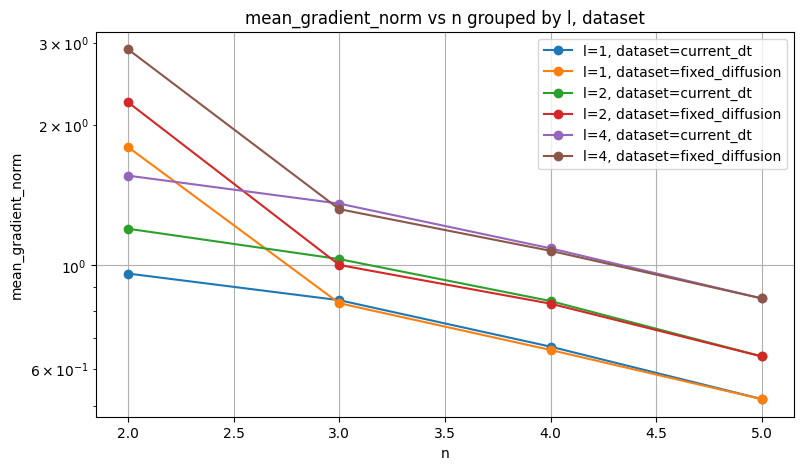

In [68]:
OVERALL_X = "n"
OVERALL_Y = "mean_gradient_norm"
OVERALL_GROUP_BY = ["l", "dataset"]  # A column, list of columns, or None

OVERALL_NS = None                # e.g. [2, 3, 4]
OVERALL_LS = None                # e.g. [1, 2, 4]
OVERALL_CIRCUITS = None          # e.g. ["multiscale_tree", "uni2"]
OVERALL_INITIAL_STATES = None    # e.g. ["positive_periodic_wave"]
OVERALL_DATASETS = None          # e.g. ["current_dt"] or ["fixed_diffusion"]

overall_plot_data, ax = an.plot_gradient_run_table(
    gradient_run_stats,
    x=OVERALL_X,
    y=OVERALL_Y,
    ns=OVERALL_NS,
    ls=OVERALL_LS,
    circuits=OVERALL_CIRCUITS,
    initial_states=OVERALL_INITIAL_STATES,
    datasets=OVERALL_DATASETS,
    group_by=OVERALL_GROUP_BY,
    kind="line",              # "line" or "scatter"
    log_x=False,
    log_y=True,
)
overall_plot_data


## Configurable plots for individual parameters

`PARAMETERS` accepts ordinary indices (`0`, `3`), negative Python-style indices (`-1` is the last parameter), and `"mid"`. The `"mid"` selector is resolved independently for every run as the middle parameter of its middle repeated circuit layer; for even counts, the later of the two middle choices is used. Group by `parameter_selection` when comparing multiple selectors.


In [ ]:
PARAMETER_X = "n"
PARAMETER_Y = "variance"
PARAMETERS = [0, 3, -1, "mid"]
PARAMETER_GROUP_BY = ["l", "dataset", "parameter_selection"]

PARAMETER_NS = None                # e.g. [2, 3, 4]
PARAMETER_LS = None                # e.g. [1, 2, 4]
PARAMETER_CIRCUITS = None          # e.g. ["multiscale_tree", "uni2"]
PARAMETER_INITIAL_STATES = None    # e.g. ["positive_periodic_wave"]
PARAMETER_DATASETS = None          # e.g. ["current_dt"]

parameter_plot_data, ax = an.plot_gradient_parameter_table(
    gradient_parameter_stats,
    x=PARAMETER_X,
    y=PARAMETER_Y,
    parameters=PARAMETERS,
    ns=PARAMETER_NS,
    ls=PARAMETER_LS,
    circuits=PARAMETER_CIRCUITS,
    initial_states=PARAMETER_INITIAL_STATES,
    datasets=PARAMETER_DATASETS,
    group_by=PARAMETER_GROUP_BY,
    kind="line",                # "line" or "scatter"
    log_x=False,
    log_y=True,
)
parameter_plot_data


## Exponential scaling fits over N

For every selected `(L, initial_state, circuit, dataset)` combination, the next cell fits variance and mean gradient norm to $y=A\,b^N$. The fit is performed as $\log y=\log A+N\log b$. If several selected runs produce the same N-point, their metric values are averaged before fitting.


,metric,l,initial_state,circuit,dataset,amplitude_A,base_b,log_base,r2_log,n_points
0,variance,1,sine,default,current_dt,1.024538,0.494628,-0.703949,0.999931,4
1,variance,2,sine,default,current_dt,1.050496,0.491208,-0.710887,0.999881,4
2,variance,4,sine,default,current_dt,1.060281,0.490628,-0.712070,0.999971,4
3,mean_gradient_norm,1,sine,default,current_dt,1.511187,0.811538,-0.208824,0.980735,4
4,mean_gradient_norm,2,sine,default,current_dt,1.879479,0.810780,-0.209758,0.982964,4
5,mean_gradient_norm,4,sine,default,current_dt,2.412983,0.815569,-0.203869,0.985148,4


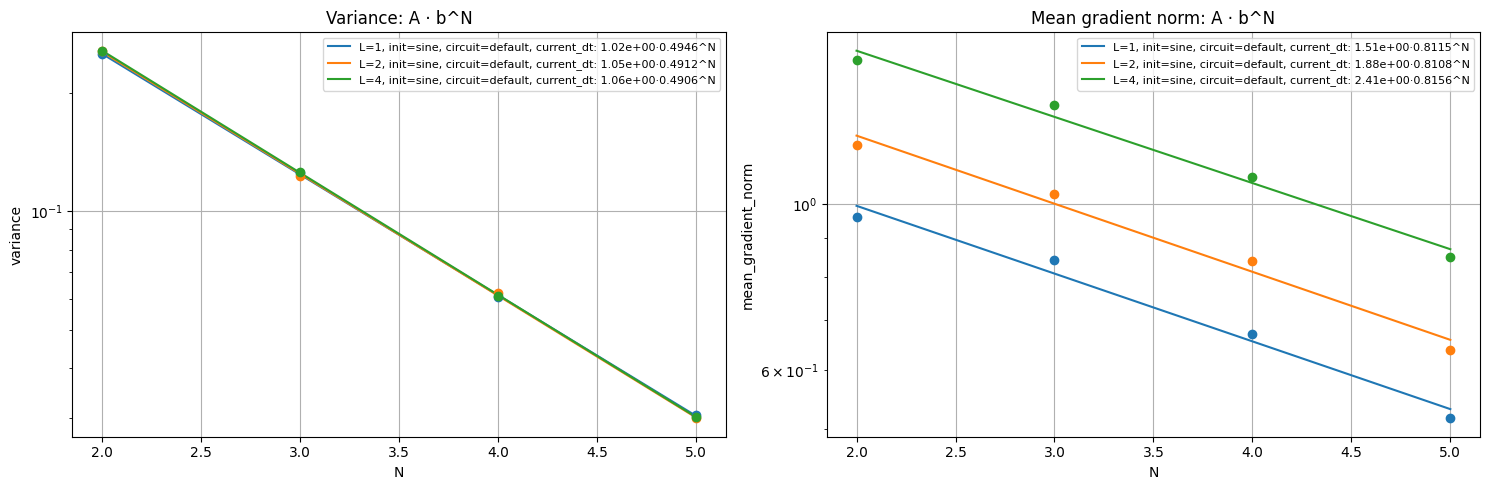

In [69]:
import pandas as pd

# Optional exact selection by full_label; leave as None to use the filters below.
FIT_RUNS = None  # e.g. ["grad_N2L1", "grad_N3L1", "grad_N4L1"]
FIT_NS = None  # e.g. [2, 3, 4, 5, 6]
FIT_LS = None  # e.g. [1, 2, 4]
FIT_INITIAL_STATES = None  # e.g. ["positive_periodic_wave"]
FIT_CIRCUITS = None  # e.g. ["multiscale_tree", "uni2"]
FIT_DATASETS = ["current_dt"]  # or ["fixed_diffusion"] / None for both

fit_data = an.filter_gradient_table(
    gradient_run_stats,
    ns=FIT_NS,
    ls=FIT_LS,
    circuits=FIT_CIRCUITS,
    initial_states=FIT_INITIAL_STATES,
    datasets=FIT_DATASETS,
)
if FIT_RUNS is not None:
    fit_run_labels = [FIT_RUNS] if isinstance(FIT_RUNS, str) else FIT_RUNS
    fit_data = fit_data[fit_data["full_label"].isin(fit_run_labels)].copy()
if fit_data.empty:
    raise ValueError("No gradient runs remain after applying the fit filters.")

group_columns = ["l", "initial_state", "circuit", "dataset"]
metrics = [("variance", "Variance"), ("mean_gradient_norm", "Mean gradient norm")]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
fit_records = []
skipped_fits = []

for ax, (metric, title) in zip(axes, metrics):
    for group_values, group in fit_data.groupby(group_columns, dropna=False, sort=True):
        points = pd.DataFrame({
            "n": pd.to_numeric(group["n"], errors="coerce"),
            metric: pd.to_numeric(group[metric], errors="coerce"),
        }).dropna()
        points = points[np.isfinite(points[metric]) & (points[metric] > 0)]
        points = points.groupby("n", as_index=False)[metric].mean().sort_values("n")

        if points["n"].nunique() < 2:
            skipped_fits.append((metric, *group_values, "fewer than two positive N-points"))
            continue

        n_values = points["n"].to_numpy(dtype=float)
        y_values = points[metric].to_numpy(dtype=float)
        log_base, log_amplitude = np.polyfit(n_values, np.log(y_values), 1)
        amplitude = float(np.exp(log_amplitude))
        base = float(np.exp(log_base))
        fitted_log_values = log_amplitude + log_base * n_values
        log_residual = np.sum((np.log(y_values) - fitted_log_values) ** 2)
        log_total = np.sum((np.log(y_values) - np.mean(np.log(y_values))) ** 2)
        r2_log = float(1 - log_residual / log_total) if log_total > 0 else np.nan

        l_value, initial_state, circuit, dataset = group_values
        group_label = f"L={l_value}, init={initial_state}, circuit={circuit}, {dataset}"
        n_fit = np.linspace(n_values.min(), n_values.max(), 200)
        fit_line, = ax.plot(
            n_fit,
            amplitude * base**n_fit,
            label=f"{group_label}: {amplitude:.2e}·{base:.4f}^N",
        )
        ax.scatter(n_values, y_values, color=fit_line.get_color(), zorder=3)
        fit_records.append({
            "metric": metric,
            "l": l_value,
            "initial_state": initial_state,
            "circuit": circuit,
            "dataset": dataset,
            "amplitude_A": amplitude,
            "base_b": base,
            "log_base": float(log_base),
            "r2_log": r2_log,
            "n_points": len(n_values),
        })

    ax.set_title(f"{title}: A · b^N")
    ax.set_xlabel("N")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if ax.has_data():
        ax.legend(fontsize=8)

fig.tight_layout()
fit_results = pd.DataFrame(fit_records)
if skipped_fits:
    print("Skipped fits:")
    for skipped in skipped_fits:
        print("  ", skipped)
fit_results


## Raw gradients

The nested dictionary below keeps the full matrices available for custom plots or statistics. Access one parameter with, for example, `gradient_matrices[run_label]["current_dt"][parameter_index]`.


In [13]:
gradient_matrices = {
    row["full_label"]: an.load_gradient_matrices(row)
    for row in selected_gradient_runs
}
{run: {dataset: values.shape for dataset, values in matrices.items()}
 for run, matrices in gradient_matrices.items()}


{'tests_N2L1': {'current_dt': (4, 1250), 'fixed_diffusion': (4, 1250)},
 'tests_N2L2': {'current_dt': (6, 833), 'fixed_diffusion': (6, 833)},
 'tests_N2L4': {'current_dt': (10, 500), 'fixed_diffusion': (10, 500)},
 'tests_N3L1': {'current_dt': (6, 833), 'fixed_diffusion': (6, 833)},
 'tests_N3L2': {'current_dt': (9, 555), 'fixed_diffusion': (9, 555)},
 'tests_N3L4': {'current_dt': (15, 333), 'fixed_diffusion': (15, 333)},
 'tests_N4L1': {'current_dt': (8, 625), 'fixed_diffusion': (8, 625)}}

In [17]:
len(gradient_matrices["tests_N2L1"]["current_dt"][0])

1250